In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from os.path import isfile, join
import pylab as plt
from glob import glob
import subprocess
import re
import math

import geopandas
from matplotlib_scalebar.scalebar import ScaleBar

from shapely import wkt

import seaborn as sns
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [2]:
rawDataDir = "/Users/swise/workspace/takamatsu/data/okazakiDemo/"
procDataDir = "/Users/swise/Projects/hitomi/data/transit/output/"

waterFloodedFile = rawDataDir + "simplifiedWater.shp"
roadsFile = rawDataDir + "simpleRoads_withInundation.shp"
stationsFile = rawDataDir + "trainStationsWithPassengers.shp"


In [3]:
# read in the list of files from the directory
workingDir = procDataDir
files = os.listdir(workingDir)
holder = {} # set up the holder
f = files[0]

In [4]:
roads = geopandas.read_file(roadsFile)
water = geopandas.read_file(waterFloodedFile)
stations = geopandas.read_file(stationsFile)

In [5]:
# helper function
def extractEvacTime(s):
    bits = s.split(',')
    record = {}
    for b in bits:
        try:
            k,v = b.split(':')
            if k[0] not in record:
                record[k] = float(v)
        except:
            pass

    if "START_EVACUATING" in record:
        startTime = record["START_EVACUATING"]
    else:
        startTime = record["START"]
    finishTime = 1440
    if "FINISH_EVAC" in record:
        finishTime = record["FINISH_EVAC"]
    elif "TRAPPED" in record:
        finishTime = record["TRAPPED"]
        
    return finishTime - startTime

In [6]:
evacueeFullData = []
evacuatingFullData = []
numTrapped = []

# extract them
for f in files:
    
    if not f.startswith("evac"):
        continue
    
    isHeatmap = "heatmap" in f
    if isHeatmap:
        continue
    
    raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file
    
    # successful evacuees
    evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
    evacTime = [extractEvacTime(s) for s in evacuees["evacuatingRecord"]]
    evacueeFullData.append(evacTime)
    
    # incomplete evacuations
    evacuees = raw_data[raw_data["status"] == "Evacuating"].reset_index()
    evacTime = [extractEvacTime(s) for s in evacuees["evacuatingRecord"]]
    evacuatingFullData.append(evacTime)
    
    # trapped
    trapped = raw_data[raw_data["status"] == "Evacuating"].reset_index()
    numTrapped.append(len(trapped))
    
#len(evacueeFullData)
print(numTrapped)
len(evacueeFullData[0])

[292, 243, 238, 250, 249, 278, 235, 262, 257, 288, 291, 246, 268, 272, 272, 285, 294, 265, 286, 258, 232, 239, 250, 259, 257, 230, 265, 233, 262, 240, 240, 292, 286, 263, 287, 274, 256, 246, 280, 284, 262, 256, 272, 260, 240, 274, 231, 262, 235]


4368

In [27]:
len(numTrapped)

49

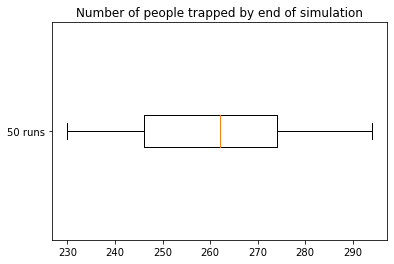

In [29]:
fig, ax = plt.subplots()
ax.set_title('Number of people trapped by end of simulation')
ax.boxplot(numTrapped, vert=False, labels=['50 runs'])
trappedFilename = "trappedDist.png"
plt.savefig(trappedFilename, format="png", dpi=720)

In [ ]:
#fig, ax = plt.subplots(ncols=1, nrows = 1, sharex=True, sharey=True, figsize=(30,24))
bins = np.linspace(0, 150, 50)


fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)

# Inset plot
#ax_inset = fig.add_axes([0.5, 0.5, 0.35, 0.3])

for inst in evacueeFullData:
    ax.hist(inst, bins, alpha=0.3, label="complete evacuation", color="red", histtype='step')
#    ax_inset.hist(inst, bins, alpha=0.3, color="red", log='y', histtype='step')
for inst in evacuatingFullData:
    ax.hist(inst, bins, alpha=0.3, label="incomplete evacuation", color="blue", histtype='step')
#    ax_inset.hist(inst, bins, alpha=0.3, color="blue", log='y', histtype='step')
ax.set_xlabel("Time spent evacuating (minutes)", fontsize=16)
ax.set_ylabel("Number of evacuees", fontsize=16)
#plt.legend(loc='upper right')

complete = mpatches.Patch(color='red', label='Complete evacuations')
incomplete = mpatches.Patch(color='blue', label='Incomplete evacuations')
ax.legend(handles=[complete, incomplete], fontsize=14, bbox_to_anchor=(0., 0.25, 1., .102))

#ax_inset.set_title("Log-scale evacuation durations")
#ax_inset.set_xlabel("minutes")
#ax_inset.set_ylabel("log(# of persons)")

plt.suptitle("Journey Time of Complete versus Incomplete Evacuations", fontsize=25)
#plt.tight_layout()
evacTimeFilename = "evacuationTimeDist_noInset.png"
plt.savefig(evacTimeFilename, format="png", dpi=720)

In [36]:
evacuees

,index,ID,age,status,evacuatingRecord,flooded,x_home,y_home,x_loc,y_loc
0,15,8447170850462448151,0,Evacuating,START:1381,inZone,696273.004946,3.862198e+06,717273.818298,3.860661e+06
1,81,-1107498776163077822,0,Evacuating,START_EVACUATING:1379.0,notSubmerged,697965.782989,3.866868e+06,717179.009285,3.860882e+06
2,163,-8669735999624120328,0,Evacuating,START_EVACUATING:1440.0,notSubmerged,692087.670588,3.877898e+06,716907.883433,3.880249e+06
3,235,3759172749643209909,0,Evacuating,START_EVACUATING:1437.0,notSubmerged,693243.765011,3.875817e+06,705944.192132,3.863339e+06
4,300,5884607883535206524,0,Evacuating,START_EVACUATING:1336.0,notSubmerged,697224.930470,3.865305e+06,704215.775916,3.875194e+06
...,...,...,...,...,...,...,...,...,...,...
230,17008,5297263515160970044,0,Evacuating,START_EVACUATING:1413.0,notSubmerged,719903.152252,3.880170e+06,697769.873406,3.865166e+06
231,17121,-6852877595279899972,0,Evacuating,START_EVACUATING:1424.0,notSubmerged,720030.840394,3.880581e+06,697367.121758,3.865826e+06
232,17124,-4315910615761120040,0,Evacuating,START_EVACUATING:1440.0,notSubmerged,714655.473669,3.874434e+06,694803.102865,3.879197e+06
233,17199,5145705816046975142,0,Evacuating,START_EVACUATING:1435.0,notSubmerged,718987.435446,3.880058e+06,702494.908776,3.860331e+06


In [30]:
def selectOnAttribute(df, targetValues, waterFile = None, exclude=False):
    
    myDf = df
    
    # select on the flooding scenario?
    if waterFile is not None:
        # pull out the runs on a specific water setting
        myDf = df[df["waterShapefile"] == waterFile]

    # make sure there's actually something to select!
    if len(targetValues) == 0:
        return myDf
        
    # iterate through, selecting on these
    for i, j in targetValues.items():
        
        if exclude:
            myDf = myDf[~myDf[i].isin(j)]
            
        else:
            myDf = myDf[myDf[i].isin(j)]            

    return myDf

In [48]:
df = evacuees
roadsFilename = roadsFile
waterFilename = waterFloodedFile
xcolname = 'x_loc'
ycolname = 'y_loc'

# select on appropriate atts
# transform this into spatial data
gdf = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(
    df[xcolname], df[ycolname]))

# aggregate by the final statuses
peopleInZone = gdf.groupby(['status'])#.agg({'ID': 'count'}).reset_index()

# initialise for the mapping phase
roads = geopandas.read_file(roadsFilename)
water = geopandas.read_file(waterFilename)

In [62]:
max(evacuees['y_loc'])

3880342.311157184

Text(0.5, 0.98, 'Unfinished Evacuees')

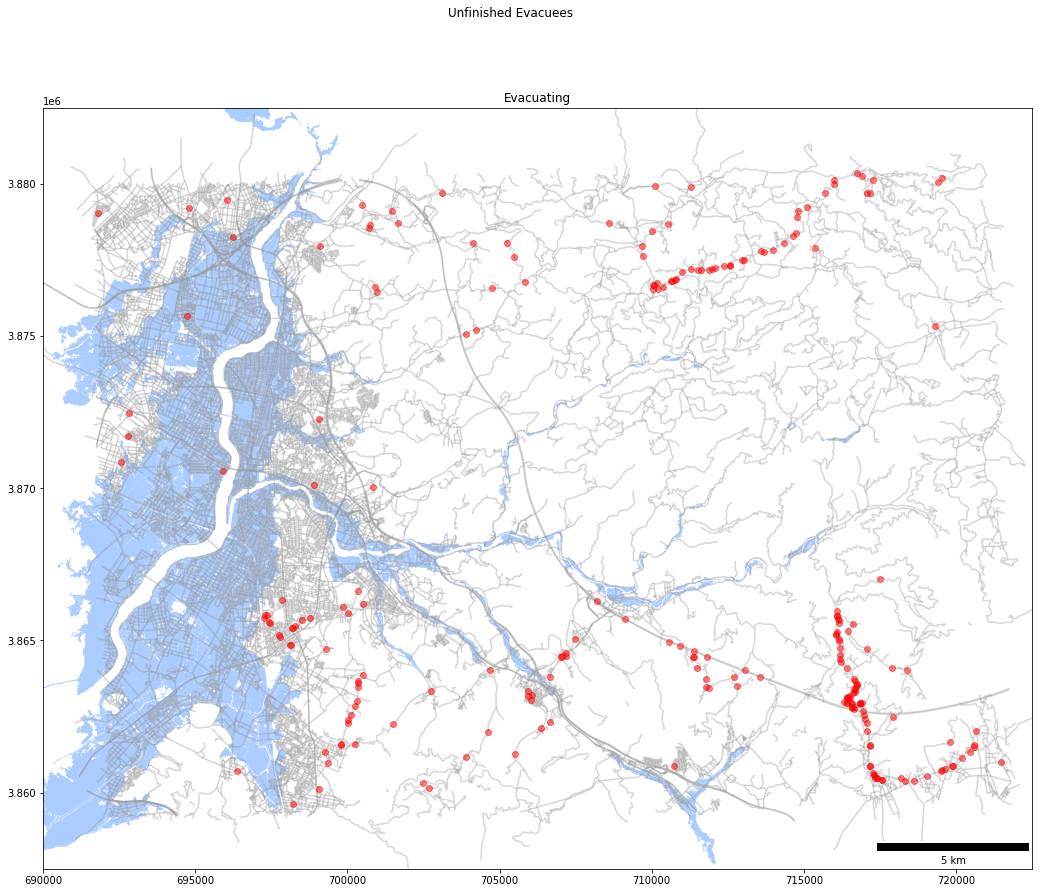

In [79]:
# set up the correct number of subplots
fig, axs = plt.subplots(ncols=1, nrows = 1, sharex=True, sharey=True, figsize=(30,14))

xlim = [690000, 722500]
ylim = [3857500, 3882500]

# iterate through the set of settings and plot them separately
for a, b in peopleInZone:

    ax = axs
    
    # plot the background and the people
    roads.plot(ax=ax, edgecolor='#999999', alpha = .4)
    water.plot(ax=ax, color='#AACCFF')
    b.plot(ax=ax, color='red', alpha=.5, zorder=2)

    # set up the title for this section
    ax.set_title(a)

    # zoom to the interesting part
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    # add a scalebar
    scalebar = ScaleBar(dx=1, location='lower right')
    ax.add_artist(scalebar)


fig.suptitle("Unfinished Evacuees")

### Sheltering in place (badly)

In [84]:
fullData = []
# extract them
for f in files:
    
    if not f.startswith("evac"):
        continue
    
    isHeatmap = "heatmap" in f
    if isHeatmap:
        continue
    
    raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file
    
    # successful evacuees
    sheltering = raw_data[raw_data["status"] == "Sheltering"].reset_index()
    fullData.append(sheltering)   

In [91]:
sum(fullData[0]["flooded"] == "inZone")

905

<AxesSubplot:>

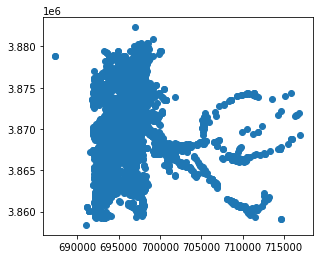

In [94]:
ex = fullData[0]

gdf.plot()

Text(0.5, 0.98, 'Sheltering In Zone')

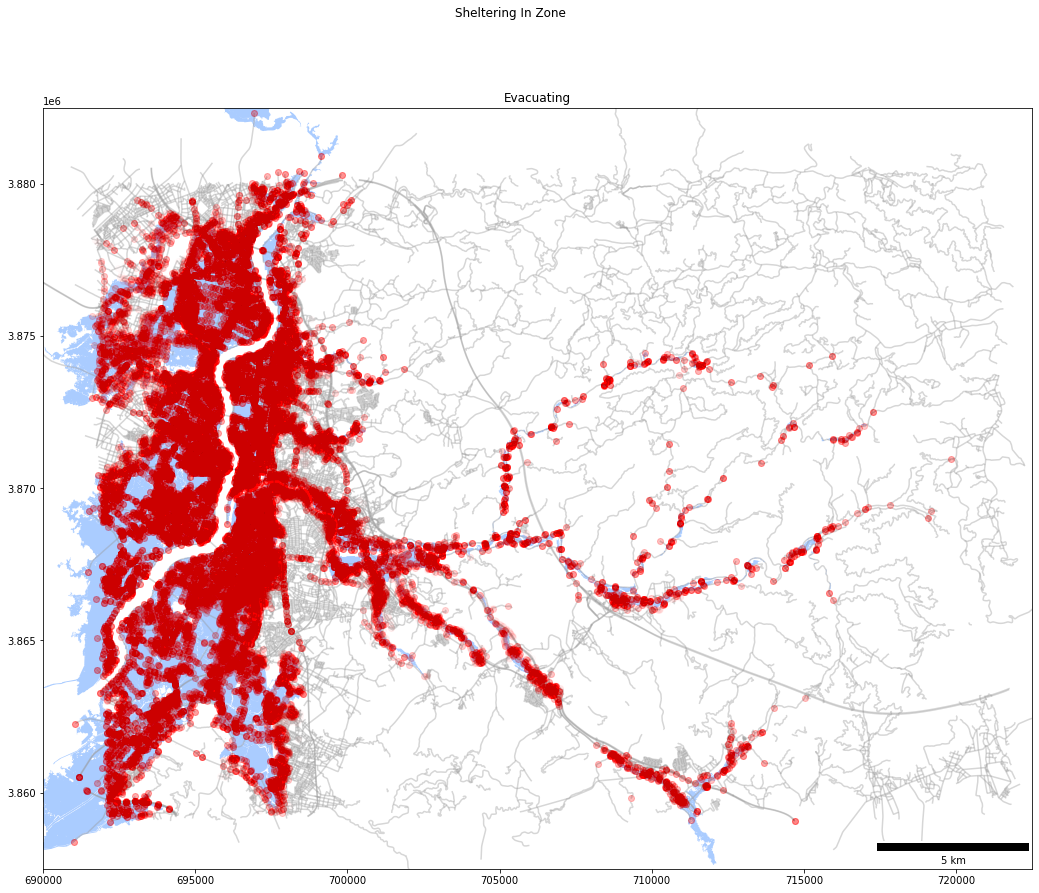

In [97]:
# set up the correct number of subplots
fig, axs = plt.subplots(ncols=1, nrows = 1, sharex=True, sharey=True, figsize=(30,14))

xlim = [690000, 722500]
ylim = [3857500, 3882500]

ax = axs
# plot the background and the people
roads.plot(ax=ax, edgecolor='#999999', alpha = .4)
water.plot(ax=ax, color='#AACCFF')


# iterate through the set of settings and plot them separately
for ex in fullData:

    gdf = geopandas.GeoDataFrame(ex, geometry=geopandas.points_from_xy(ex[xcolname], ex[ycolname]))
    
    gdf.plot(ax=ax, color='red', alpha=.02, zorder=2)


# set up the title for this section
ax.set_title(a)

# zoom to the interesting part
ax.set_xlim(xlim)
ax.set_ylim(ylim)
    
# add a scalebar
scalebar = ScaleBar(dx=1, location='lower right')
ax.add_artist(scalebar)

fig.suptitle("Sheltering In Zone")

In [ ]:
sns.set_style('white')

exportMapByScenario(holder, "hicss_stillEvacuating_flooded.png", "Unfinished Evacuation Locations", waterFloodedFile, roadsFile, includeAtts ={'status': ['Evacuating']})